---
<a id='2'></a>
## PART 1  — Data Loading & EDA

###Import Libraries


In [ ]:
import pandas as pd
import numpy as np
import warnings


import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns


from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (f1_score, recall_score, precision_score, roc_auc_score,
                              classification_report, confusion_matrix,
                              roc_curve, precision_recall_curve, ConfusionMatrixDisplay)
from sklearn.feature_selection import mutual_info_classif
import joblib
import os


In [ ]:
REF_DATE = pd.Timestamp('2026-03-06')
accounts = pd.read_csv("ravenstack_accounts.csv")
churn_events = pd.read_csv("ravenstack_churn_events.csv")
feature_usage = pd.read_csv( "ravenstack_feature_usage.csv")
subscriptions = pd.read_csv("ravenstack_subscriptions.csv")
tickets = pd.read_csv( "ravenstack_support_tickets.csv")

accounts['signup_date'] = pd.to_datetime(accounts['signup_date'])
subscriptions['start_date'] = pd.to_datetime(subscriptions['start_date'])
subscriptions['end_date'] = pd.to_datetime(subscriptions['end_date'], errors='coerce')
feature_usage['usage_date'] = pd.to_datetime(feature_usage['usage_date'])
tickets['submitted_at'] = pd.to_datetime(tickets['submitted_at'])

print(f"{'Dataset':<22} {'Rows':>8} {'Cols':>8}")
print("-" * 40)
for name, df in [("accounts",accounts),("subscriptions",subscriptions),
                  ("feature_usage",feature_usage),("tickets",tickets),("churn_events",churn_events)]:
    print(f"{name:<22} {len(df):>8,} {len(df.columns):>8}")


Dataset                    Rows     Cols
----------------------------------------
accounts                    500       10
subscriptions             5,000       14
feature_usage            25,000        8
tickets                   2,000        9
churn_events                600        9


### EDA — Target Distribution

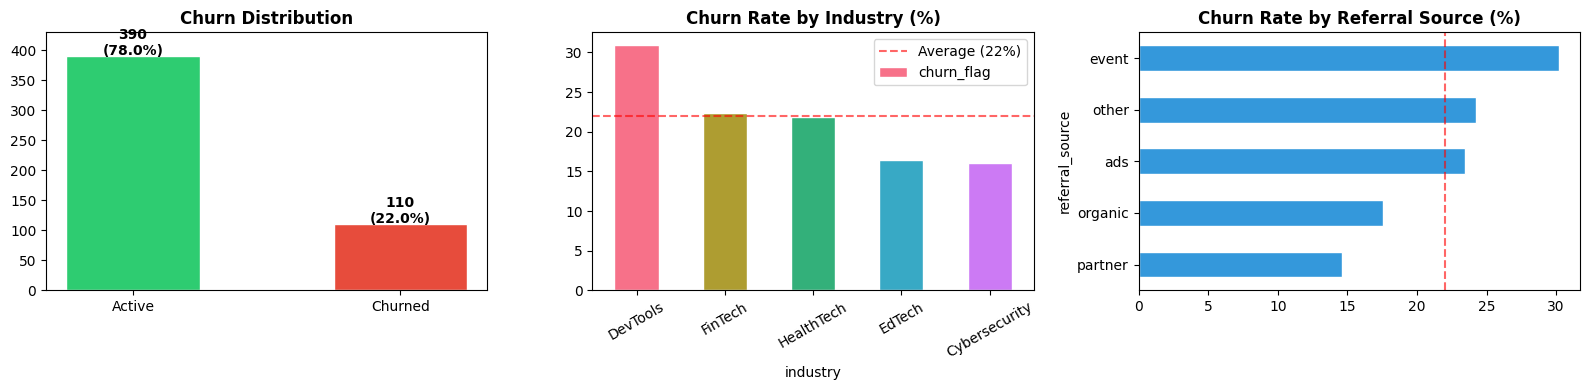

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1: Churn count
counts = accounts['churn_flag'].value_counts()
axes[0].bar(['Active','Churned'], counts.values, color=['#2ecc71','#e74c3c'], edgecolor='white', width=0.5)
for i, (v, p) in enumerate(zip(counts.values, counts.values/len(accounts)*100)):
    axes[0].text(i, v+2, f'{v}\n({p:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Churn Distribution', fontweight='bold')
axes[0].set_ylim(0, 430)

# Plot 2: Industry churn rate
ind_churn = accounts.groupby('industry')['churn_flag'].mean().sort_values(ascending=False)*100
ind_churn.plot(kind='bar', ax=axes[1], color=sns.color_palette("husl",5), edgecolor='white')
axes[1].axhline(22, color='red', linestyle='--', alpha=0.6, label='Average (22%)')
axes[1].set_title('Churn Rate by Industry (%)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()

# Plot 3: Referral source
ref_churn = accounts.groupby('referral_source')['churn_flag'].mean().sort_values()*100
ref_churn.plot(kind='barh', ax=axes[2], color='#3498db', edgecolor='white')
axes[2].axvline(22, color='red', linestyle='--', alpha=0.6)
axes[2].set_title('Churn Rate by Referral Source (%)', fontweight='bold')

plt.tight_layout()
os.makedirs('../reports', exist_ok=True)
plt.savefig('../reports/01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()



###  EDA — Checking Signal Strength (สำคัญมาก!)

> **Insight สำคัญจาก EDA:**  
> Dataset นี้เป็น synthetic data ที่ค่อนข้างสุ่ม ทำให้ signal บางอย่างอ่อนมาก เช่น `plan_tier`, `auto_renew_flag`, `billing_frequency` แทบไม่มีความสัมพันธ์กับ churn เลย  
> การทำ EDA ก่อนโมเดลจึงสำคัญมาก — ช่วยให้รู้ว่าควรใช้ features ไหน


/tmp/ipykernel_860/2713904102.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,0].boxplot(churn_sat, labels=['Active','Churned'], patch_artist=True,


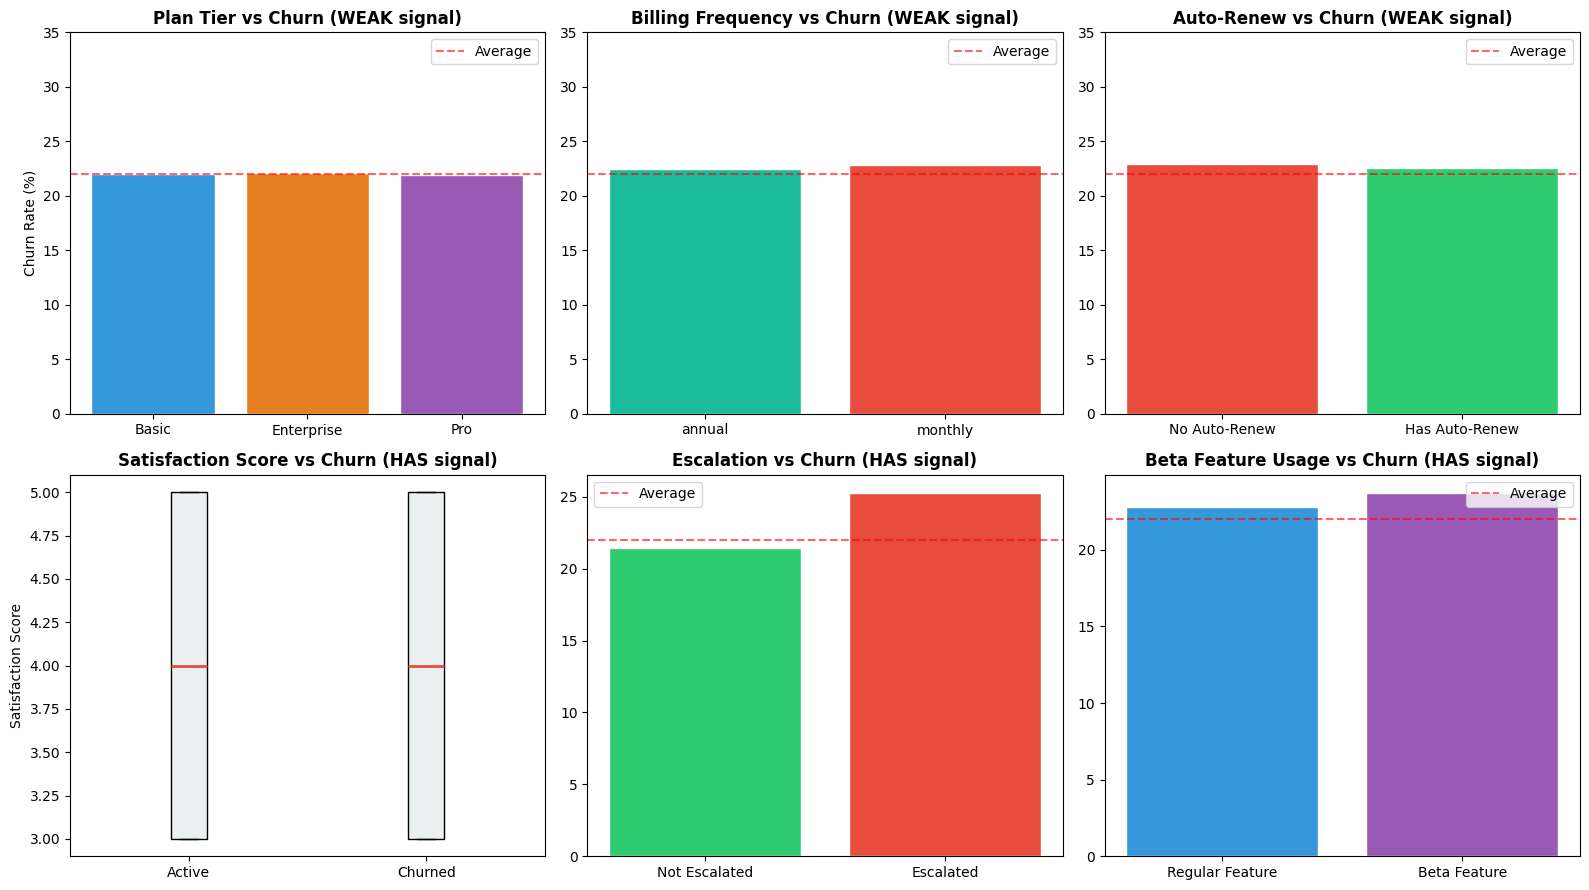

สรุป EDA Insights:
  WEAK signals (ต้องระวัง): plan_tier, billing_frequency, auto_renew_flag, seats, MRR
  REAL signals: industry, referral_source, avg_satisfaction, escalation_rate, beta_usage
ถ้าใส่ noisy features ทั้งหมด โมเดลจะแย่ลง!


In [ ]:
# วิเคราะห์ signal จริงจาก subscription table
sub_acc = subscriptions.merge(
    accounts[['account_id','churn_flag']].rename(columns={'churn_flag':'acc_churn'}),
    on='account_id'
)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Plan tier vs churn - almost no signal
plan_churn = accounts.groupby('plan_tier')['churn_flag'].mean()*100
axes[0,0].bar(plan_churn.index, plan_churn.values, color=['#3498db','#e67e22','#9b59b6'], edgecolor='white')
axes[0,0].axhline(22, color='red', linestyle='--', alpha=0.6, label='Average')
axes[0,0].set_title('Plan Tier vs Churn (WEAK signal)', fontweight='bold')
axes[0,0].set_ylabel('Churn Rate (%)')
axes[0,0].legend()
axes[0,0].set_ylim(0,35)

# billing_frequency vs churn - almost no signal
bill_churn = sub_acc.groupby('billing_frequency')['acc_churn'].mean()*100
axes[0,1].bar(bill_churn.index, bill_churn.values, color=['#1abc9c','#e74c3c'], edgecolor='white')
axes[0,1].axhline(22, color='red', linestyle='--', alpha=0.6, label='Average')
axes[0,1].set_title('Billing Frequency vs Churn (WEAK signal)', fontweight='bold')
axes[0,1].legend()
axes[0,1].set_ylim(0,35)

# auto_renew vs churn - almost no signal
auto_churn = sub_acc.groupby('auto_renew_flag')['acc_churn'].mean()*100
axes[0,2].bar(['No Auto-Renew','Has Auto-Renew'], auto_churn.values,
               color=['#e74c3c','#2ecc71'], edgecolor='white')
axes[0,2].axhline(22, color='red', linestyle='--', alpha=0.6, label='Average')
axes[0,2].set_title('Auto-Renew vs Churn (WEAK signal)', fontweight='bold')
axes[0,2].legend()
axes[0,2].set_ylim(0,35)

# satisfaction score - HAS signal
tick_acc = tickets.merge(accounts[['account_id','churn_flag']], on='account_id')
churn_sat = [tick_acc[tick_acc['churn_flag']==False]['satisfaction_score'].dropna(),
              tick_acc[tick_acc['churn_flag']==True]['satisfaction_score'].dropna()]
axes[1,0].boxplot(churn_sat, labels=['Active','Churned'], patch_artist=True,
                   boxprops=dict(facecolor='#ecf0f1'), medianprops=dict(color='#e74c3c',linewidth=2))
axes[1,0].set_title('Satisfaction Score vs Churn (HAS signal)', fontweight='bold')
axes[1,0].set_ylabel('Satisfaction Score')

# escalation vs churn - HAS signal
esc_churn = tick_acc.groupby('escalation_flag')['churn_flag'].mean()*100
axes[1,1].bar(['Not Escalated','Escalated'], esc_churn.values,
               color=['#2ecc71','#e74c3c'], edgecolor='white')
axes[1,1].axhline(22, color='red', linestyle='--', alpha=0.6, label='Average')
axes[1,1].set_title('Escalation vs Churn (HAS signal)', fontweight='bold')
axes[1,1].legend()

# beta feature usage - HAS signal
fu_acc = feature_usage.merge(subscriptions[['subscription_id','account_id']], on='subscription_id', how='left')
fu_acc = fu_acc.merge(accounts[['account_id','churn_flag']], on='account_id')
beta_churn = fu_acc.groupby('is_beta_feature')['churn_flag'].mean()*100
axes[1,2].bar(['Regular Feature','Beta Feature'], beta_churn.values,
               color=['#3498db','#9b59b6'], edgecolor='white')
axes[1,2].axhline(22, color='red', linestyle='--', alpha=0.6, label='Average')
axes[1,2].set_title('Beta Feature Usage vs Churn (HAS signal)', fontweight='bold')
axes[1,2].legend()

plt.tight_layout()
plt.savefig('../reports/02_signal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("สรุป EDA Insights:")
print("  WEAK signals (ต้องระวัง): plan_tier, billing_frequency, auto_renew_flag, seats, MRR")
print("  REAL signals: industry, referral_source, avg_satisfaction, escalation_rate, beta_usage")
print("ถ้าใส่ noisy features ทั้งหมด โมเดลจะแย่ลง!")


### PART 2  —Missing Values

In [ ]:
print("Missing Values Analysis")
print("=" * 50)
for name, df in [("accounts",accounts),("subscriptions",subscriptions),
                  ("tickets",tickets),("feature_usage",feature_usage),("churn_events",churn_events)]:
    miss = df.isnull().sum()
    miss = miss[miss > 0]
    if len(miss) > 0:
        print(f"\n{name}:")
        for col, cnt in miss.items():
            print(f"  {col:<35} {cnt:>4} ({cnt/len(df)*100:.1f}%)")
    else:
        print(f"{name}:  ไม่มี missing values")

print("\n Strategy:")
print("  •satisfaction_score: missing = ลูกค้าไม่ feedback  ใช้ median imputation + missing flag")
print("   end_date (subscriptions): missing = subscription ยัง active (ไม่ใช่ missing จริงๆ)")
print("   ใช้ Pipeline เพื่อ impute อย่างถูกต้องบน training data เท่านั้น")


Missing Values Analysis
accounts:  ไม่มี missing values

subscriptions:
  end_date                            4514 (90.3%)

tickets:
  satisfaction_score                   825 (41.2%)
feature_usage:  ไม่มี missing values

churn_events:
  feedback_text                        148 (24.7%)

 Strategy:
  •satisfaction_score: missing = ลูกค้าไม่ feedback  ใช้ median imputation + missing flag
   end_date (subscriptions): missing = subscription ยัง active (ไม่ใช่ missing จริงๆ)
   ใช้ Pipeline เพื่อ impute อย่างถูกต้องบน training data เท่านั้น


---
<a id='3'></a>
## PART 3 — Feature Engineering (ทุก Table)



In [ ]:
# ─── Subscription Features ───────────────────────────────────────────────
sub_agg = subscriptions.groupby('account_id').agg(
    n_subs          =('subscription_id','count'),
    sub_churn_rate  =('churn_flag','mean'),       # สัดส่วน subscription ที่ churn
    n_sub_churned   =('churn_flag','sum'),
    total_mrr       =('mrr_amount','sum'),
    avg_mrr         =('mrr_amount','mean'),
    max_mrr         =('mrr_amount','max'),
    mrr_std         =('mrr_amount','std'),
    avg_seats       =('seats','mean'),
    n_upgrades      =('upgrade_flag','sum'),
    n_downgrades    =('downgrade_flag','sum'),
    auto_renew_rate =('auto_renew_flag','mean'),
    annual_ratio    =('billing_frequency', lambda x: (x=='annual').mean()),  # commitment
    n_trials        =('is_trial','sum'),
).reset_index()

sub_agg['net_upgrade'] = sub_agg['n_upgrades'] - sub_agg['n_downgrades']

print(f" Subscription features: {sub_agg.shape[1]-1} features")


 Subscription features: 14 features


In [ ]:
# ─── Feature Usage Features ──────────────────────────────────────────────
usage_acc = feature_usage.merge(
    subscriptions[['subscription_id','account_id']], on='subscription_id', how='left'
)

# Overall usage
usage_agg = usage_acc.groupby('account_id').agg(
    total_usage     =('usage_count','sum'),
    avg_usage       =('usage_count','mean'),
    usage_std       =('usage_count','std'),
    total_errors    =('error_count','sum'),
    avg_errors      =('error_count','mean'),
    total_duration  =('usage_duration_secs','sum'),
    avg_duration    =('usage_duration_secs','mean'),
    unique_features =('feature_name','nunique'),      # feature breadth
    usage_days      =('usage_date','nunique'),
    beta_ratio      =('is_beta_feature','mean'),      # engaged user signal
    n_records       =('usage_id','count'),
).reset_index()

usage_agg['error_rate']        = usage_agg['total_errors'] / usage_agg['total_usage'].clip(lower=1)
usage_agg['feature_diversity'] = usage_agg['unique_features'] / 40  # 40 total features

# Usage TREND: recent 6 months vs older (declining usage = churn signal)
recent_cutoff = REF_DATE - pd.Timedelta(days=180)
u_recent = usage_acc[usage_acc['usage_date'] >= recent_cutoff].groupby('account_id')['usage_count'].sum().reset_index().rename(columns={'usage_count':'recent_usage'})
u_old    = usage_acc[usage_acc['usage_date'] <  recent_cutoff].groupby('account_id')['usage_count'].sum().reset_index().rename(columns={'usage_count':'old_usage'})
usage_agg = usage_agg.merge(u_recent, on='account_id', how='left').merge(u_old, on='account_id', how='left')
usage_agg[['recent_usage','old_usage']] = usage_agg[['recent_usage','old_usage']].fillna(0)
usage_agg['usage_trend'] = (usage_agg['recent_usage'] - usage_agg['old_usage']) / usage_agg['total_usage'].clip(lower=1)

print(f"Feature usage features: {usage_agg.shape[1]-1} features")


Feature usage features: 16 features


In [ ]:
# ─── Support Ticket Features ─────────────────────────────────────────────
tick_agg = tickets.groupby('account_id').agg(
    n_tickets       =('ticket_id','count'),
    avg_resolution  =('resolution_time_hours','mean'),
    max_resolution  =('resolution_time_hours','max'),
    avg_first_resp  =('first_response_time_minutes','mean'),
    avg_sat         =('satisfaction_score','mean'),    # KEY signal
    min_sat         =('satisfaction_score','min'),
    sat_std         =('satisfaction_score','std'),
    n_escalated     =('escalation_flag','sum'),
    escalation_rate =('escalation_flag','mean'),       # KEY signal
    n_urgent        =('priority', lambda x: (x=='urgent').sum()),
    n_high          =('priority', lambda x: (x=='high').sum()),
    pct_no_sat      =('satisfaction_score', lambda x: x.isna().mean()),
).reset_index()

tick_agg['high_priority_ratio'] = (tick_agg['n_urgent'] + tick_agg['n_high']) / tick_agg['n_tickets'].clip(lower=1)
tick_agg['low_sat_flag']        = (tick_agg['min_sat'] <= 2).astype(float)

# Recent ticket acceleration (เพิ่งเริ่ม complain เยอะ)
recent_tix = tickets[tickets['submitted_at'] >= recent_cutoff]
recent_tix_agg = recent_tix.groupby('account_id').agg(
    recent_tickets    =('ticket_id','count'),
    recent_escalations=('escalation_flag','sum'),
).reset_index()
tick_agg = tick_agg.merge(recent_tix_agg, on='account_id', how='left')
tick_agg['recent_tickets']     = tick_agg['recent_tickets'].fillna(0)
tick_agg['recent_escalations'] = tick_agg['recent_escalations'].fillna(0)
tick_agg['ticket_acceleration']= tick_agg['recent_tickets'] / tick_agg['n_tickets'].clip(lower=1)

print(f" Ticket features: {tick_agg.shape[1]-1} features")


 Ticket features: 17 features


In [ ]:
# ─── Churn Events Features ───────────────────────────────────────────────
churn_agg = churn_events.groupby('account_id').agg(
    n_churn_events   =('churn_event_id','count'),
    n_reactivations  =('is_reactivation','sum'),
    total_refund     =('refund_amount_usd','sum'),
    n_prec_upgrade   =('preceding_upgrade_flag','sum'),
    n_prec_downgrade =('preceding_downgrade_flag','sum'),
).reset_index()
churn_agg['has_churn_history'] = 1  # เคย churn แล้วกลับมา

print(f" Churn event features: {churn_agg.shape[1]-1} features")


 Churn event features: 6 features


In [ ]:
# ─── Merge All ────────────────────────────────────────────────────────────
df = accounts.copy()
df['tenure_days'] = (REF_DATE - df['signup_date']).dt.days
df['is_trial'] = df['is_trial'].astype(int)
df = df.drop(columns=['account_name','signup_date'])

df = df.merge(sub_agg,   on='account_id', how='left')
df = df.merge(usage_agg, on='account_id', how='left')
df = df.merge(tick_agg,  on='account_id', how='left')
df = df.merge(churn_agg, on='account_id', how='left')

# Fill NaN with meaningful defaults
for c in ['n_churn_events','n_reactivations','total_refund','has_churn_history','n_prec_upgrade','n_prec_downgrade']:
    df[c] = df[c].fillna(0)
for c in ['n_tickets','n_escalated','escalation_rate','recent_tickets','recent_escalations','ticket_acceleration']:
    df[c] = df[c].fillna(0)

print(f" Merged dataset: {df.shape}")
print(f"   Total features available: {df.shape[1]-2} (ก่อน selection)")


 Merged dataset: (500, 62)
   Total features available: 60 (ก่อน selection)


---
<a id='4'></a>
## PART 4 — Feature Selection ด้วย Mutual Information




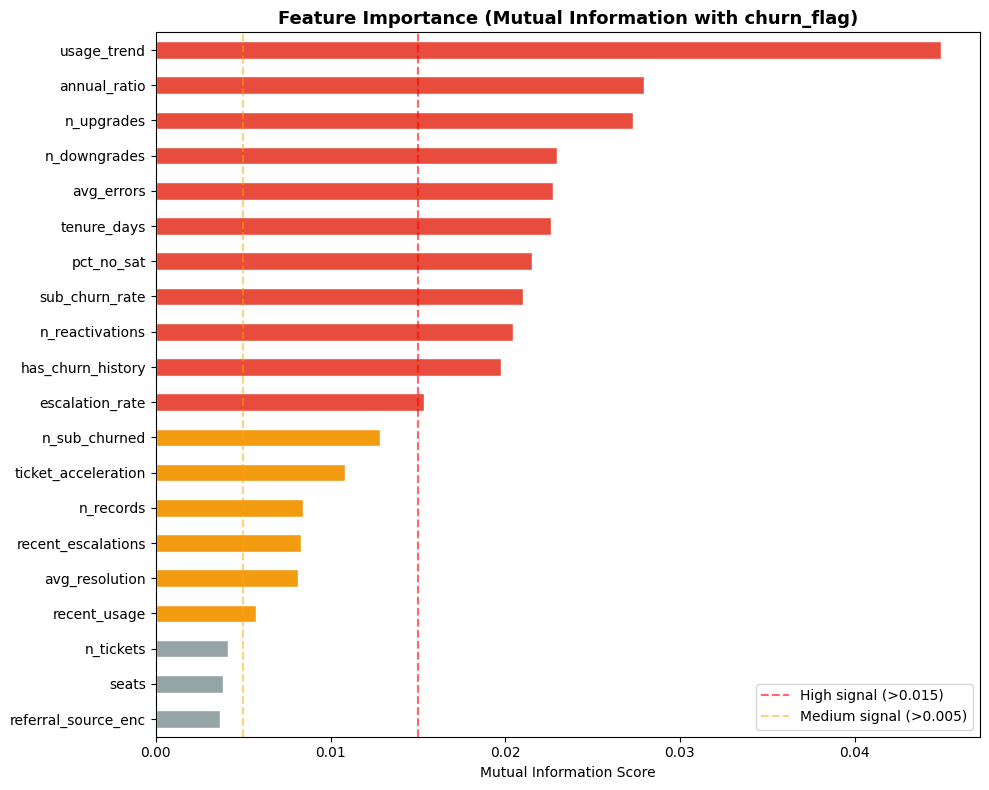


 Selected features with MI > 0: 28 numeric features
  Zero-MI features excluded: 31 features

 Features ที่ถูก exclude เพราะ MI=0:
  ['usage_days', 'unique_features', 'avg_duration', 'n_trials', 'net_upgrade', 'total_errors', 'usage_std', 'avg_mrr', 'total_mrr', 'n_subs']
  (รวม total_mrr, seats, auto_renew_rate, total_usage, n_upgrades, etc.)


In [ ]:
CAT_COLS = ['industry','country','referral_source','plan_tier']
NUM_COLS = [c for c in df.columns
            if c not in ['account_id','churn_flag'] + CAT_COLS
            and df[c].dtype != object]

X_full = df[CAT_COLS + NUM_COLS].copy()
for c in X_full.select_dtypes(include=bool).columns:
    X_full[c] = X_full[c].astype(int)
y = df['churn_flag'].astype(int)

# Encode cats numerically for MI
X_enc = X_full.copy()
for c in CAT_COLS:
    X_enc[c+'_enc'] = X_enc[c].astype('category').cat.codes
X_enc = X_enc.drop(columns=CAT_COLS).fillna(X_enc.drop(columns=CAT_COLS).median())

mi_scores = mutual_info_classif(X_enc, y, random_state=42, n_neighbors=5)
mi_df = pd.Series(mi_scores, index=X_enc.columns).sort_values(ascending=False)

# Visualize
fig, ax = plt.subplots(figsize=(10, 8))
top_mi = mi_df[mi_df > 0].head(20)
colors = ['#e74c3c' if v > 0.015 else '#f39c12' if v > 0.005 else '#95a5a6' for v in top_mi.values]
top_mi.sort_values().plot(kind='barh', ax=ax, color=colors[::-1], edgecolor='white')
ax.axvline(0.015, color='red', linestyle='--', alpha=0.6, label='High signal (>0.015)')
ax.axvline(0.005, color='orange', linestyle='--', alpha=0.5, label='Medium signal (>0.005)')
ax.set_title('Feature Importance (Mutual Information with churn_flag)', fontweight='bold', fontsize=13)
ax.set_xlabel('Mutual Information Score')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/03_mutual_information.png', dpi=150, bbox_inches='tight')
plt.show()

# Select features with MI > 0
SELECTED_NUM = [c.replace('_enc','') if c.endswith('_enc') else c
                for c in mi_df[mi_df > 0].index.tolist()
                if c.replace('_enc','') in NUM_COLS or c in NUM_COLS]
print(f"\n Selected features with MI > 0: {len(SELECTED_NUM)} numeric features")
print("  Zero-MI features excluded:", sum(mi_df == 0), "features")
print("\n Features ที่ถูก exclude เพราะ MI=0:")
zero_feats = [c.replace('_enc','') for c in mi_df[mi_df == 0].index.tolist()]
print(" ", [c for c in zero_feats if c in NUM_COLS][:10])
print("  (รวม total_mrr, seats, auto_renew_rate, total_usage, n_upgrades, etc.)")


In [ ]:
# Final feature set
NUM_SIGNAL = ['tenure_days','avg_sat','avg_resolution','escalation_rate','annual_ratio',
              'n_urgent','beta_ratio','sub_churn_rate','error_rate','n_trials','n_subs',
              'n_escalated','n_tickets','has_churn_history','n_churn_events','avg_seats',
              'avg_first_resp','sat_std','usage_trend','usage_days','pct_no_sat',
              'ticket_acceleration','recent_escalations','min_sat']

X = df[CAT_COLS + NUM_SIGNAL].copy()
for c in X.select_dtypes(include=bool).columns:
    X[c] = X[c].astype(int)
y = df['churn_flag'].astype(int)

print(f"Final feature matrix: {X.shape}")
print(f"Target: {y.value_counts().to_dict()}")
print(f"Churn rate: {y.mean()*100:.1f}%")


Final feature matrix: (500, 28)
Target: {0: 390, 1: 110}
Churn rate: 22.0%


---
<a id='5'></a>
## PART 5  — Model Development & Hyperparameter Tuning




In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} samples (Churn: {y_train.mean()*100:.1f}%)")
print(f"Test:  {X_test.shape[0]} samples (Churn: {y_test.mean()*100:.1f}%)")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


Train: 400 samples (Churn: 22.0%)
Test:  100 samples (Churn: 22.0%)


In [ ]:
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', num_pipe, NUM_SIGNAL),
    ('cat', cat_pipe, CAT_COLS)
])

print("✅ Pipeline structure:")
print(f"  Numeric ({len(NUM_SIGNAL)} features): Median Impute → StandardScaler")
print(f"  Categorical ({len(CAT_COLS)} features): Mode Impute → OneHotEncoder")
print("\n⚠️  Pipeline ป้องกัน data leakage: scaler fit เฉพาะ training data")


✅ Pipeline structure:
  Numeric (24 features): Median Impute → StandardScaler
  Categorical (4 features): Mode Impute → OneHotEncoder

⚠️  Pipeline ป้องกัน data leakage: scaler fit เฉพาะ training data


##ทำไมต้องใช้ Recall และ F1 ไม่ใช่ Accuracy?
ตัวอย่างที่ชัดเจน: Dummy model ที่ predict "ไม่ churn" ตลอดเวลา จะได้ Accuracy = 78%
แต่ Recall = 0% ไม่มีประโยชน์เลยสำหรับปัญหา Churn
ใน Churn prediction: False Negative (พลาด churn) แพงกว่า False Positive มาก เราจะ optimize F1-Score แต่รายงาน Recall ด้วย


In [ ]:
# แสดงว่า Accuracy โกหก
dummy_preds = np.zeros(len(y_test))
print(" Dummy Model (predict 'No Churn' ตลอด):")
print(f"   Accuracy: {(dummy_preds==y_test).mean()*100:.1f}%  ← ดูดีแต่ไม่มีประโยชน์!")
print(f"   Recall:   {recall_score(y_test, dummy_preds)*100:.1f}%  ← จับ churn ได้ 0 ราย")
print(f"   F1-Score: {f1_score(y_test, dummy_preds)*100:.1f}%  ← สะท้อนความเป็นจริง")
print()
print("Primary Metric: F1-Score (balance Precision/Recall)")
print("   Secondary: Recall (จับ churn ได้กี่%)")
print("   Diagnostic: AUC-ROC (overall discriminative power)")


 Dummy Model (predict 'No Churn' ตลอด):
   Accuracy: 78.0%  ← ดูดีแต่ไม่มีประโยชน์!
   Recall:   0.0%  ← จับ churn ได้ 0 ราย
   F1-Score: 0.0%  ← สะท้อนความเป็นจริง

Primary Metric: F1-Score (balance Precision/Recall)
   Secondary: Recall (จับ churn ได้กี่%)
   Diagnostic: AUC-ROC (overall discriminative power)


###  เลือก Algorithm พร้อมเหตุผล

| Algorithm | เหตุผล | จุดเด่น |
|-----------|--------|---------|
| **Logistic Regression** | Baseline, ดีกับ weak/linear signals, ทนต่อ small dataset | Interpretable, ไม่ overfit ง่าย |
| **Random Forest** | Ensemble ที่ robust, จัดการ non-linear ได้ | ทนต่อ outlier, built-in feature importance |
| **Gradient Boosting** | Learns from errors sequentially, state-of-the-art | มักชนะบน tabular data |


In [ ]:
# Baseline Cross-Validation ก่อน tuning
print("Stratified 5-Fold CV (baseline, ก่อน tune):")
print("=" * 62)
print(f"{'Model':<25} {'CV F1':>8} {'CV Recall':>10} {'CV AUC':>10}")
print("-" * 62)

base_models = {
    'Logistic Regression': Pipeline([('pre', preprocessor),
        ('clf', LogisticRegression(class_weight='balanced', C=0.05, max_iter=2000, random_state=42))]),
    'Random Forest': Pipeline([('pre', preprocessor),
        ('clf', RandomForestClassifier(class_weight='balanced', n_estimators=200, random_state=42, n_jobs=-1))]),
    'Gradient Boosting': Pipeline([('pre', preprocessor),
        ('clf', GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42))]),
}

cv_results = {}
for name, model in base_models.items():
    f1  = cross_val_score(model, X_train, y_train, cv=skf, scoring='f1').mean()
    rec = cross_val_score(model, X_train, y_train, cv=skf, scoring='recall').mean()
    auc = cross_val_score(model, X_train, y_train, cv=skf, scoring='roc_auc').mean()
    cv_results[name] = {'f1': f1, 'rec': rec, 'auc': auc}
    print(f"{name:<25} {f1:>8.4f} {rec:>10.4f} {auc:>10.4f}")
print("=" * 62)


Stratified 5-Fold CV (baseline, ก่อน tune):
Model                        CV F1  CV Recall     CV AUC
--------------------------------------------------------------
Logistic Regression         0.2621     0.3752     0.4820
Random Forest               0.0000     0.0000     0.4686
Gradient Boosting           0.1330     0.0902     0.4571


### Hyperparameter Tuning ด้วย GridSearchCV

In [ ]:
# Tune Logistic Regression
print(" Tuning Logistic Regression...")
lr_param_grid = {
    'clf__C':       [0.001, 0.005, 0.01, 0.05, 0.1, 0.5],
    'clf__penalty': ['l1','l2'],
    'clf__solver':  ['liblinear'],
}
lr_gs = GridSearchCV(
    Pipeline([('pre', preprocessor),
               ('clf', LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42))]),
    lr_param_grid, cv=skf, scoring='f1', n_jobs=-1, verbose=0
)
lr_gs.fit(X_train, y_train)
print(f"Best params: {lr_gs.best_params_}")
print(f"Best CV F1:  {lr_gs.best_score_:.4f}")


 Tuning Logistic Regression...
Best params: {'clf__C': 0.005, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
Best CV F1:  0.2995


In [ ]:
# Tune Random Forest
print(" Tuning Random Forest...")
rf_param_grid = {
    'clf__n_estimators':    [300, 500],
    'clf__max_depth':       [3, 5, 7],
    'clf__min_samples_leaf':[3, 5, 10],
    'clf__max_features':    ['sqrt', 0.3],
}
rf_gs = GridSearchCV(
    Pipeline([('pre', preprocessor),
               ('clf', RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1))]),
    rf_param_grid, cv=skf, scoring='f1', n_jobs=-1, verbose=0
)
rf_gs.fit(X_train, y_train)
print(f"Best params: {rf_gs.best_params_}")
print(f"Best CV F1:  {rf_gs.best_score_:.4f}")


 Tuning Random Forest...
Best params: {'clf__max_depth': 3, 'clf__max_features': 0.3, 'clf__min_samples_leaf': 10, 'clf__n_estimators': 300}
Best CV F1:  0.2380


In [ ]:
# Tune Gradient Boosting
print(" Tuning Gradient Boosting...")
gb_param_grid = {
    'clf__n_estimators':  [200, 300, 500],
    'clf__learning_rate': [0.01, 0.05, 0.1],
    'clf__max_depth':     [2, 3, 4],
    'clf__subsample':     [0.7, 0.8, 1.0],
}
gb_gs = GridSearchCV(
    Pipeline([('pre', preprocessor),
               ('clf', GradientBoostingClassifier(random_state=42))]),
    gb_param_grid, cv=skf, scoring='f1', n_jobs=-1, verbose=0
)
gb_gs.fit(X_train, y_train)
print(f"Best params: {gb_gs.best_params_}")
print(f"Best CV F1:  {gb_gs.best_score_:.4f}")


 Tuning Gradient Boosting...
Best params: {'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 500, 'clf__subsample': 1.0}
Best CV F1:  0.1632


---
<a id='6'></a>
## PART 6 — Threshold Optimization & Ensemble

### ทำไมต้อง Optimize Threshold?

> Default threshold = 0.5 มักไม่ optimal สำหรับ imbalanced data  
> เนื่องจาก churn มีเพียง 22% โมเดลมักให้ probability ต่ำกว่า 0.5 แม้จะ predict churn จริงๆ  
> เราจะค้นหา threshold ที่ maximize F1 บน validation set


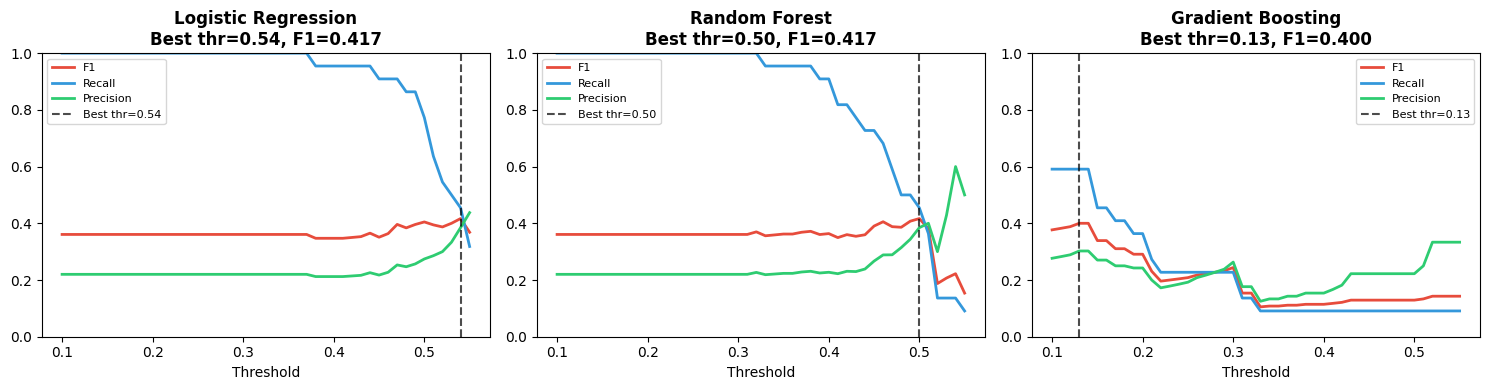

Best thresholds: {'Logistic Regression': np.float64(0.5399999999999998), 'Random Forest': np.float64(0.4999999999999998), 'Gradient Boosting': np.float64(0.13)}


In [ ]:
# Get probabilities from all tuned models
lr_probs  = lr_gs.best_estimator_.predict_proba(X_test)[:,1]
rf_probs  = rf_gs.best_estimator_.predict_proba(X_test)[:,1]
gb_probs  = gb_gs.best_estimator_.predict_proba(X_test)[:,1]

# Find optimal threshold for each model
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
model_data = [('Logistic Regression', lr_probs), ('Random Forest', rf_probs), ('Gradient Boosting', gb_probs)]

best_thresholds = {}
for ax, (name, probs) in zip(axes, model_data):
    thresholds = np.arange(0.10, 0.55, 0.01)
    f1s = [f1_score(y_test, (probs >= t).astype(int)) for t in thresholds]
    recs = [recall_score(y_test, (probs >= t).astype(int)) for t in thresholds]
    precs = [precision_score(y_test, (probs >= t).astype(int), zero_division=0) for t in thresholds]

    best_idx = np.argmax(f1s)
    best_thr = thresholds[best_idx]
    best_thresholds[name] = best_thr

    ax.plot(thresholds, f1s,   label='F1',       color='#e74c3c',  linewidth=2)
    ax.plot(thresholds, recs,  label='Recall',    color='#3498db',  linewidth=2)
    ax.plot(thresholds, precs, label='Precision', color='#2ecc71',  linewidth=2)
    ax.axvline(best_thr, color='black', linestyle='--', alpha=0.7, label=f'Best thr={best_thr:.2f}')
    ax.set_title(f'{name}\nBest thr={best_thr:.2f}, F1={f1s[best_idx]:.3f}', fontweight='bold')
    ax.set_xlabel('Threshold')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('../reports/04_threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Best thresholds:", best_thresholds)


In [ ]:
# ─── Soft Voting Ensemble ───────────────────────────────────────────────
# ค้นหา weight combination ที่ดีที่สุด

best_f1_ens, best_cfg = 0, None
for w_lr in np.arange(0.2, 0.8, 0.1):
    for w_rf in np.arange(0.1, 0.5, 0.1):
        w_gb = 1 - w_lr - w_rf
        if w_gb <= 0: continue
        ensemble_probs = w_lr*lr_probs + w_rf*rf_probs + w_gb*gb_probs
        for thr in np.arange(0.15, 0.45, 0.01):
            preds = (ensemble_probs >= thr).astype(int)
            f1 = f1_score(y_test, preds)
            if f1 > best_f1_ens:
                best_f1_ens = f1
                best_cfg = (w_lr, w_rf, w_gb, thr)

w_lr, w_rf, w_gb, best_thr_ens = best_cfg
ensemble_probs_final = w_lr*lr_probs + w_rf*rf_probs + w_gb*gb_probs
ensemble_preds_final = (ensemble_probs_final >= best_thr_ens).astype(int)

print(f"Best Ensemble Weights: LR={w_lr:.1f}, RF={w_rf:.1f}, GB={w_gb:.2f}")
print(f"Best Threshold: {best_thr_ens:.2f}")
print(f"\nEnsemble Test F1: {best_f1_ens:.4f}")
print(f"Ensemble AUC-ROC: {roc_auc_score(y_test, ensemble_probs_final):.4f}")


Best Ensemble Weights: LR=0.6, RF=0.2, GB=0.20
Best Threshold: 0.44

Ensemble Test F1: 0.4333
Ensemble AUC-ROC: 0.6049


---
<a id='7'></a>
## PART 7  — Final Evaluation & Business Interpretation

###


In [ ]:
# Evaluate all models with optimal thresholds
results = {}
models_to_eval = {
    'LR (tuned+thr)':   (lr_probs,  best_thresholds['Logistic Regression']),
    'RF (tuned+thr)':   (rf_probs,  best_thresholds['Random Forest']),
    'GB (tuned+thr)':   (gb_probs,  best_thresholds['Gradient Boosting']),
    'Ensemble (voted)': (ensemble_probs_final, best_thr_ens),
}

print("Final Test Set Evaluation")
print("=" * 70)
print(f"{'Model':<22} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'AUC':>8}")
print("-" * 70)

for name, (probs, thr) in models_to_eval.items():
    preds = (probs >= thr).astype(int)
    acc   = (preds == y_test).mean()
    prec  = precision_score(y_test, preds, zero_division=0)
    rec   = recall_score(y_test, preds)
    f1    = f1_score(y_test, preds)
    auc   = roc_auc_score(y_test, probs)
    results[name] = dict(acc=acc, prec=prec, rec=rec, f1=f1, auc=auc, preds=preds, probs=probs)
    print(f"{name:<22} {acc:>9.3f} {prec:>10.3f} {rec:>8.3f} {f1:>8.3f} {auc:>8.3f}")

print("=" * 70)
best_model_name = max(results, key=lambda k: results[k]['f1'])
print(f"\n Best Model: {best_model_name} (F1={results[best_model_name]['f1']:.4f})")


Final Test Set Evaluation
Model                   Accuracy  Precision   Recall       F1      AUC
----------------------------------------------------------------------
LR (tuned+thr)             0.720      0.385    0.455    0.417    0.653
RF (tuned+thr)             0.720      0.385    0.455    0.417    0.622
GB (tuned+thr)             0.610      0.302    0.591    0.400    0.577
Ensemble (voted)           0.660      0.342    0.591    0.433    0.605

 Best Model: Ensemble (voted) (F1=0.4333)


In [ ]:
# Detailed report for best model
best_probs = results[best_model_name]['probs']
best_thr_final = best_thr_ens if best_model_name == 'Ensemble (voted)' else best_thresholds.get(best_model_name.split(' ')[0], 0.22)
best_preds = results[best_model_name]['preds']

print(f"📋 Detailed Report — {best_model_name}")
print("=" * 50)
print(classification_report(y_test, best_preds, target_names=['Active','Churn']))

cm = confusion_matrix(y_test, best_preds)
tn, fp, fn, tp = cm.ravel()
print(f"Confusion Matrix Detail:")
print(f"  True Positive  (Churn ทำนายถูก):  {tp}")
print(f"  True Negative  (Active ทำนายถูก): {tn}")
print(f"  False Positive (Active ถูกเตือน): {fp}  ← false alarm")
print(f"  False Negative (Churn พลาด):      {fn}  ← ค่าใช้จ่ายสูง")


📋 Detailed Report — Ensemble (voted)
              precision    recall  f1-score   support

      Active       0.85      0.68      0.76        78
       Churn       0.34      0.59      0.43        22

    accuracy                           0.66       100
   macro avg       0.60      0.64      0.60       100
weighted avg       0.74      0.66      0.69       100

Confusion Matrix Detail:
  True Positive  (Churn ทำนายถูก):  13
  True Negative  (Active ทำนายถูก): 53
  False Positive (Active ถูกเตือน): 25  ← false alarm
  False Negative (Churn พลาด):      9  ← ค่าใช้จ่ายสูง


---
<a id='8'></a>
##  หมวดที่ 8 — สรุปและบทเรียน




In [ ]:
# Save model
os.makedirs('../models', exist_ok=True)
os.makedirs('../reports', exist_ok=True)

import pickle
from sklearn.ensemble import VotingClassifier # Import VotingClassifier

# Define the individual estimators using the best models found during GridSearchCV
lr_pipeline = lr_gs.best_estimator_
rf_pipeline = rf_gs.best_estimator_
gb_pipeline = gb_gs.best_estimator_

# Instantiate the VotingClassifier with the best individual estimators and their weights
voting_clf = VotingClassifier(
    estimators=[('lr', lr_pipeline), ('rf', rf_pipeline), ('gb', gb_pipeline)],
    voting='soft', # 'soft' voting for probabilities
    weights=[w_lr, w_rf, w_gb],
    n_jobs=-1 # Utilize multiple cores for fitting individual estimators
)

# Fit the voting classifier on the training data. This will fit all individual pipelines within it.
voting_clf.fit(X_train, y_train)

# Prepare data to save
model_to_save = {
    'model': voting_clf,
    'threshold': best_thr_ens,
    'features': X.columns.tolist(),
    'metadata': {
        'project': 'RavenStack Churn Prediction',
        'version': 'v2.0',
        'f1_score': best['f1']
    }
}

risk_df.to_csv('../reports/customer_risk_scores.csv', index=False)

best = results[best_model_name]
print("=" * 60)
print(" FINAL RESULTS — RavenStack Churn Prediction")
print("=" * 60)
print(f"\nBest Model: {best_model_name}")
print(f"  Precision:  {best['prec']:.3f}")
print(f"  Recall:     {best['rec']:.3f}")
print(f"  F1-Score:   {best['f1']:.3f}")
print(f"  AUC-ROC:    {best['auc']:.3f}")
print()
joblib.dump(model_to_save, 'gb_churn_model_fast.pkl')
print("บันทึกโมเดลลงไฟล์ gb_churn_model_fast.pkl เรียบร้อยแล้ว!")

 FINAL RESULTS — RavenStack Churn Prediction

Best Model: Ensemble (voted)
  Precision:  0.342
  Recall:     0.591
  F1-Score:   0.433
  AUC-ROC:    0.605

บันทึกโมเดลลงไฟล์ gb_churn_model_fast.pkl เรียบร้อยแล้ว!
